In [10]:
# Exercise 4
# Task 1

import numpy as np
matrix = np.ones((5,5))

matrix[1:-1,1:-1] = 0
print(matrix)

# Task 2
np.random.seed(42)
random_data =np.random.randn(100,3)
normalized = (random_data - random_data.mean(axis = 0)) / random_data.std(axis = 0)

mean = np.mean(normalized)
std = np.std(normalized)
print("Mean:",mean)
print("Std:",std)

# Task 3
X = np.random.randn(50, 3)
true_theta = np.array([2.5, -1.2, 3.7])
y = X @ true_theta + np.random.randn(50) * 0.1
theta_hat = np.linalg.inv(X.T @ X) @ X.T @ y
print("Theta hat: " , theta_hat)

print("True Theta: " ,true_theta)


[[1. 1. 1. 1. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 1. 1. 1. 1.]]
Mean: -1.1842378929335004e-17
Std: 1.0000000000000002
Theta hat:  [ 2.51723721 -1.19783796  3.72399266]
True Theta:  [ 2.5 -1.2  3.7]


In [19]:
# Exercise 5
import pandas as pd
import numpy as np

np.random.seed(42)
n_students = 200

data = {
    'student_id': range(1000, 1000 + n_students),
    'major': np.random.choice(['CS', 'Math', 'Physics', 'Biology'], n_students),
    'year': np.random.choice([1, 2, 3, 4], n_students),
    'exam_score': np.random.normal(75, 10, n_students).clip(0, 100),
    'assignments_completed': np.random.randint(0, 11, n_students),
    'hours_studied': np.random.normal(15, 5, n_students).clip(1, 40)
}

df = pd.DataFrame(data)

df.loc[np.random.choice(n_students, 10), 'exam_score'] = np.nan
df.loc[np.random.choice(n_students, 5), 'hours_studied'] = np.nan

# Task 1
# Display basic information about the dataset
print(df.info())

# Identify and count missing values
print(df.isnull().sum())

# Fill missing exam_score with the mean score for the student's major
df['exam_score'] = df['exam_score'].fillna(df.groupby('major')['exam_score'].transform('mean'))

#Fill missing hours_studied with the median for the student's year
df['hours_studied'] = df['hours_studied'].fillna(
    df.groupby('year')['hours_studied'].transform('median')
)


# Task 2
# Calculate and display the average exam_score by major
average_scores = df.groupby('major')['exam_score'].mean()
print(average_scores)

# Find the major with the highest average exam_score
highest_major = average_scores.idxmax() # I used AI to understand the use of 'idxmax'
print("Major with highest average score: ", highest_major)

# Calculate the correlation between hours_studied and exam_score
correlation =df['hours_studied'].corr(df['exam_score'])
print("Correlation: ",correlation)

# Create a new column 'performance' with categories:
# 'Excellent' (>90), 'Good' (80-90), 'Average' (70-80), 'Needs Improvement' (<70)
def performance(score):
    if score > 90:
        return "Excellent"
    elif score >= 80:
        return "Good"
    elif score >= 70:
        return "Average"
    elif score < 70:
        return "Needs Improvement"

df['performance'] = df["exam_score"].apply(performance) # I used AI to determine the use of apply in this line

print(df.head(10))

# Task 3
# For each major and year combination, calculate:
#       - Number of students
#       - Average exam score
#       - Average hours studied
summary = df.groupby(['major','year']).agg(num_student=('exam_score', 'count'),avg_score=('exam_score', 'mean'),avg_hours_studied=('hours_studied', 'count'))

print("Summary: ", summary)

# Identify top 5 students based on exam_score (handle ties appropriately)
top_students = df.sort_values('exam_score',ascending=False).head(5)
print("Top students: " ,top_students)

# Create a pivot table showing average exam_score by major (rows) and year (columns)
pivot = df.pivot_table(values='exam_score',index='major',columns='year',aggfunc='mean') # I  used AI in determining how to create a pivot table
print(pivot)



<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             200 non-null    int64  
 1   major                  200 non-null    str    
 2   year                   200 non-null    int64  
 3   exam_score             190 non-null    float64
 4   assignments_completed  200 non-null    int32  
 5   hours_studied          195 non-null    float64
dtypes: float64(2), int32(1), int64(2), str(1)
memory usage: 8.7 KB
None
student_id                0
major                     0
year                      0
exam_score               10
assignments_completed     0
hours_studied             5
dtype: int64
major
Biology    75.503150
CS         76.425184
Math       74.683689
Physics    75.406509
Name: exam_score, dtype: float64
Major with highest average score:  CS
Correlation:  -0.05598138347292447
   student_id    major  year  exam_score 

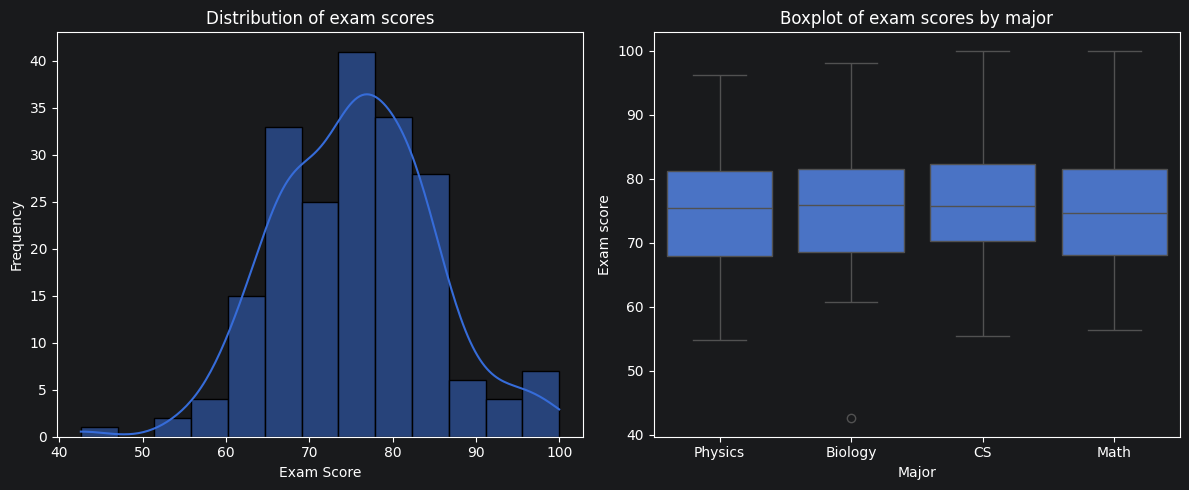

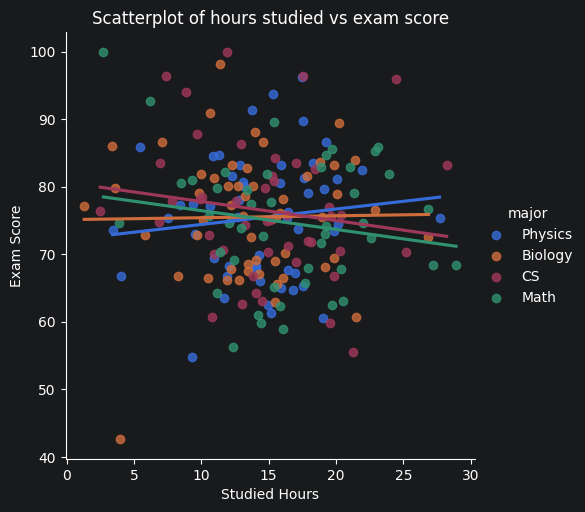

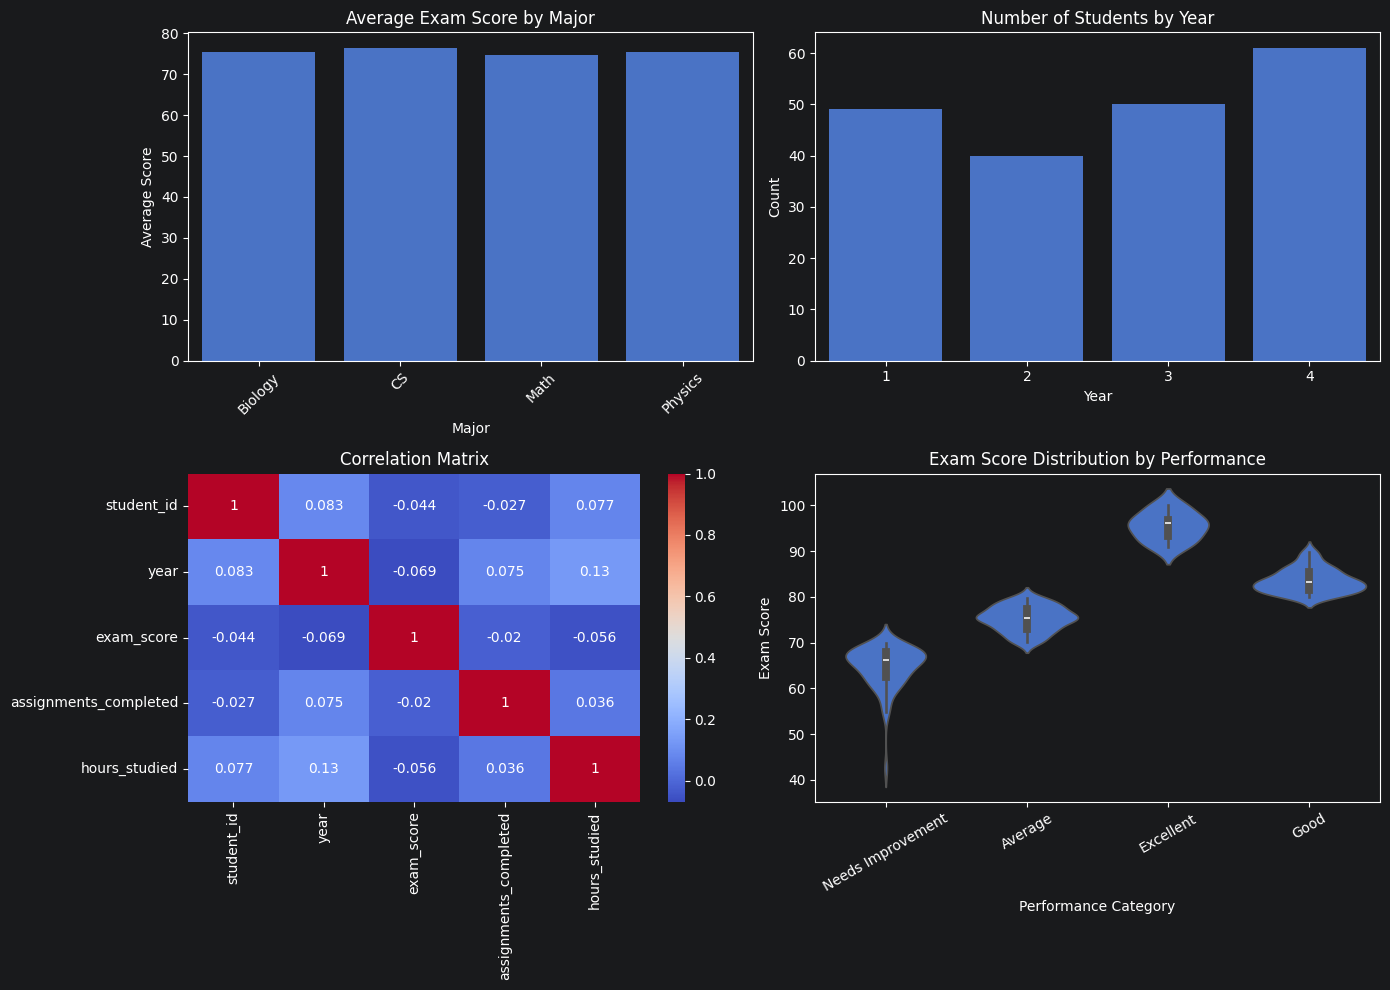

In [25]:
# Exercise 6
import matplotlib.pyplot as plt
import seaborn as sns

# Task 1: Distribution Visualization (8 points)
# Create a figure with 2 subplots side by side
# Add appropriate titles, labels, and styling
fig, ax = plt.subplots(1,2,figsize=(12,5))

# Left: Histogram of exam scores with KDE overlay
sns.histplot(df['exam_score'],ax=ax[0],kde=True)
ax[0].set_title("Distribution of exam scores")
ax[0].set_xlabel("Exam Score")
ax[0].set_ylabel("Frequency")

# Right: Box plot of exam scores by major
sns.boxplot(x='major',y='exam_score',data=df,ax=ax[1])
ax[1].set_title("Boxplot of exam scores by major")
ax[1].set_xlabel("Major")
ax[1].set_ylabel("Exam score")

plt.tight_layout() # I used AI to help me have a better layout in this line
plt.show()


# Task 2: Relationship Visualization (8 points)
# Create a scatter plot of hours_studied vs exam_score
# Color points by major
# Add a regression line
# Include appropriate legends, titles, and axis labels

sns.lmplot(data=df,x='hours_studied',y='exam_score',hue ='major',ci=None)
plt.title("Scatterplot of hours studied vs exam score")
plt.xlabel("Studied Hours")
plt.ylabel("Exam Score")
plt.show()


# Task 3: Advanced Dashboard (9 points)
# Create a 2x2 subplot figure containing:
fig,ax = plt.subplots(2,2,figsize=(14,10))
# 1. Bar chart: Average exam score by major
avg_major = df.groupby('major')['exam_score'].mean().reset_index()
sns.barplot(data=avg_major, x='major', y='exam_score', ax=ax[0, 0])
ax[0, 0].set_title('Average Exam Score by Major')
ax[0, 0].set_xlabel('Major')
ax[0, 0].set_ylabel('Average Score')
ax[0, 0].tick_params(axis='x', rotation=45)

# 2. Count plot: Number of students by year
sns.countplot(data=df, x='year', ax=ax[0, 1])
ax[0, 1].set_title('Number of Students by Year')
ax[0, 1].set_xlabel('Year')
ax[0, 1].set_ylabel('Count')

# 3. Heat map: Correlation matrix of numerical columns
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', ax=ax[1, 0]) # I used AI to determine how to find the correlation
ax[1, 0].set_title('Correlation Matrix')

# 4. Violin plot: Exam score distribution by performance category
sns.violinplot(data=df, x='performance', y='exam_score', ax=ax[1, 1])  # I used AI to know how to make a violin plot
ax[1, 1].set_title('Exam Score Distribution by Performance')
ax[1, 1].set_xlabel('Performance Category')
ax[1, 1].set_ylabel('Exam Score')
ax[1, 1].tick_params(axis='x', rotation=30)

# Adjust layout, add titles, and ensure readability
plt.tight_layout()
plt.show()





Age summary:             num_customers    avg_income     avg_CLV      total_CLV
age_group                                                        
18-25                 69  51805.879852  704.492597   48609.989225
26-35                 73  48747.148046  747.738562   54584.915035
36-50                160  48516.895668  732.796612  117247.457917
51-70                186  50713.163384  762.693498  141860.990683
     age        income  purchase_frequency  avg_purchase_value  churn_risk  \
426   42  68713.567863                   8          154.285448    0.333333   
213   41  45580.608009                   7          164.920221    0.416667   
410   44  49344.934596                   6          177.097211    0.500000   
194   44  57331.964922                   6          176.640590    0.500000   
244   28  29255.076913                   7          159.784979    0.416667   
423   43  34443.666248                   6          173.245130    0.500000   
386   63  24200.782005                   9  

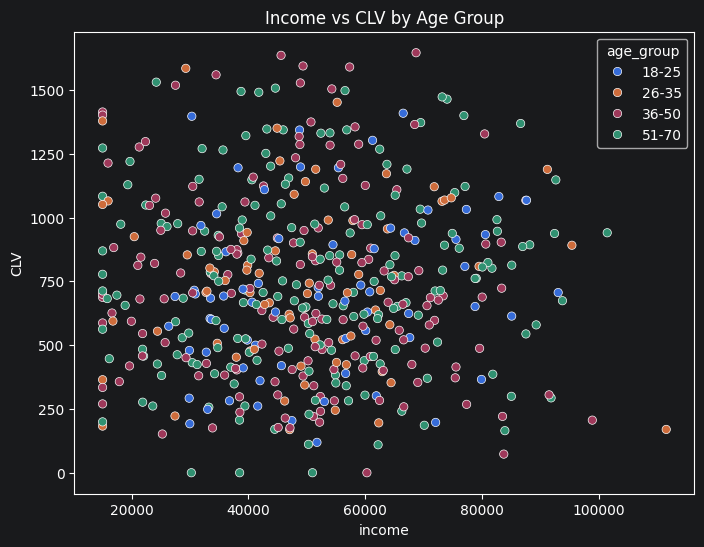

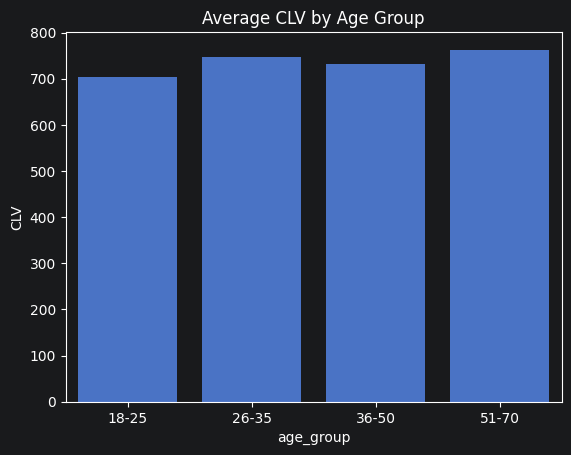

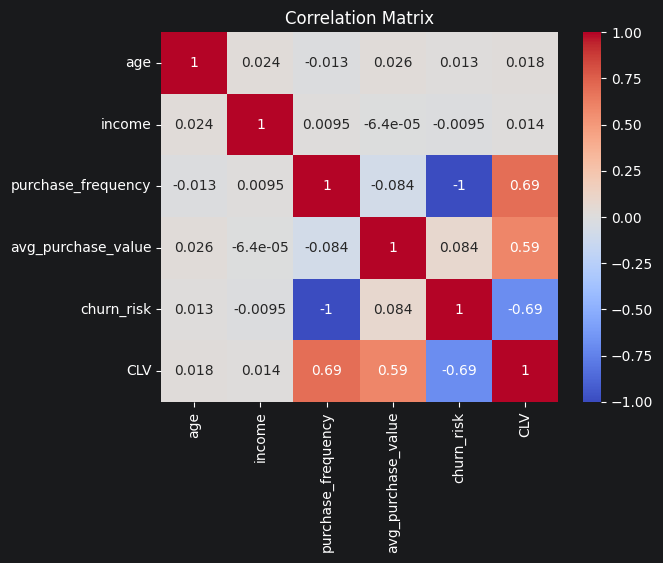

In [26]:
# Exercise 7
np.random.seed(42)
n_customers = 500

# Generate customer data
ages = np.random.randint(18, 70, n_customers)
income = np.random.normal(50000, 20000, n_customers).clip(15000, 150000)
purchase_freq = np.random.poisson(5, n_customers)
avg_purchase_value = np.random.normal(100, 30, n_customers).clip(10, 500)

# Create DataFrame
customers = pd.DataFrame({
    'age': ages,
    'income': income,
    'purchase_frequency': purchase_freq,
    'avg_purchase_value': avg_purchase_value
})

# Calculate customer lifetime value (CLV)
max_frequency = customers['purchase_frequency'].max()
customers['churn_risk'] = 1 - (customers['purchase_frequency'] / max_frequency)
customers['CLV'] = customers['purchase_frequency'] * customers['avg_purchase_value'] * (1 + customers['churn_risk'])

# Create age groups: 18-25, 26-35, 36-50, 51-70
customers['age_group'] = pd.cut(
    customers['age'],
    [18, 25, 35, 50, 70],
    labels=['18-25', '26-35', '36-50', '51-70']
) # I used AI to help me segment the ages.

# For each age group, calculate:
# - Number of customers
# - Average income
# - Average CLV
# - Total CLV

age_summary = customers.groupby('age_group').agg(
    num_customers=('age', 'count'),
    avg_income=('income', 'mean'),
    avg_CLV=('CLV', 'mean'),
    total_CLV=('CLV', 'sum')
)

print("Age summary: ", age_summary)

# Identify top 10% of customers by CLV
top_customers = customers.nlargest(int(0.1 * len(customers)), 'CLV')

print(top_customers)

# Create visualizations:
# 1. Scatter plot of income vs CLV (color by age group)
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=customers,
    x='income',
    y='CLV',
    hue='age_group'
)

plt.title('Income vs CLV by Age Group')
plt.show()

# 2. Bar chart of average CLV by age group
avg_clv = customers.groupby('age_group')['CLV'].mean().reset_index()

sns.barplot(data=avg_clv, x='age_group', y='CLV')

plt.title('Average CLV by Age Group')
plt.show()

# 3. Correlation heatmap
sns.heatmap(customers.corr(numeric_only=True), annot=True, cmap='coolwarm')

plt.title('Correlation Matrix')
plt.show()

The results make one thing very clear: how often customers buy and how much they spend each time play a big role in their overall value to the company. Customers between 26–35 and 36–50 stand out as the real heavyweights. They regularly generate the highest customer lifetime value. Income also matters, but not very much. There’s a steady trend where higher earners tend to spend more.What’s especially striking is how concentrated the value is: the top 10% of customers are responsible for a large chunk of total revenue. For the company, this suggests a two-part strategy. Double down on keeping those high-value age groups engaged and loyal, while also finding smarter ways to connect with lower-performing segments so they can gradually increase their spending and engagement over time